# Formativa 2 — Modelamiento Predictivo (práctica)
**MCDI501 · Grupo 4 · Bank Marketing UCI**

Práctica formativa (0 %) que prepara la Sumativa 3. Construida explícitamente sobre los resultados de S1 y S2.

In [1]:
# §§0 — Configuración global
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

# Detección dinámica de la raíz del proyecto
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent
RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'

df = pd.read_csv(RUTA_CSV, sep=';')
df['y_bin'] = (df['y'] == 'yes').astype(int)
print(f'Dataset cargado: {df.shape}')
print(f'Tasa de suscripción: {df["y_bin"].mean():.4f} '
      f'({df["y_bin"].sum():,} yes / {(df["y_bin"]==0).sum():,} no)')


Dataset cargado: (41188, 22)
Tasa de suscripción: 0.1127 (4,640 yes / 36,548 no)


## §1 — Preparación de datos para modelamiento

### 1.1 Hallazgos relevantes de S1 y S2

**Sumativa 1 — resultados clave:**

| Análisis | Resultado | Implicancia |
|---|---|---|
| IC 95 % `age` | [39.92, 40.12] | Estimador robusto, efecto pequeño (d=0.096) |
| IC 95 % `euribor3m` | [3.60, 3.64] | Variable macroeconómica estable |
| IC 95 % `nr.employed` | [5166.3, 5167.7] | Alta multicolinealidad con `euribor3m` |
| Prueba t edad (yes vs no) | p=1.80×10⁻⁶, d=0.096 | Significativa pero efecto pequeño |
| Chi² `poutcome` vs `y` | V Cramér=0.32 | Efecto grande — **feature de alta prioridad** |
| Desbalance de clases | 88.7 % no / 11.3 % yes | Usar F1 y AUC-ROC como métricas principales |

**Sumativa 2 — correlaciones validadas (IC bootstrap 95 %, 10.000 remuestras):**

| Par | r medio | IC 95 % | Estabilidad |
|---|---|---|---|
| `euribor3m` vs `nr.employed` | 0.945 | [0.944, 0.946] | Alta multicolinealidad — elegir una |
| `euribor3m` vs `emp.var.rate` | 0.972 | [0.972, 0.973] | Alta multicolinealidad — excluir |
| `euribor3m` vs `y_bin` | −0.308 | [−0.318, −0.298] | **Robusta, usar en modelo** |
| `previous` vs `y_bin` | 0.230 | [0.216, 0.245] | **Robusta, usar en modelo** |
| `age` vs `y_bin` | 0.031 | [0.018, 0.043] | Significativa, magnitud baja |

**Outliers (S2 §5):** `age`: 469 obs. (1.14 %) fuera de [9.5, 69.5] años (Tukey). Sin influyentes en `euribor3m` ni `nr.employed` (jackknife LOO).

**Restricciones metodológicas:**
- `duration` excluida — proxy post-hoc del target (data leakage)
- Usar solo una entre `euribor3m`, `emp.var.rate`, `nr.employed` (r > 0.94)
- `pdays=999` recodificar a binaria (contactado / no contactado)

In [2]:
# §1.2 — Revisión de valores faltantes y unknowns
print('=== Valores NaN reales ===')
nans = df.isnull().sum()
print(nans[nans > 0].to_string() if nans.any() else 'Ninguno')

print('\n=== Frecuencia de unknown por variable categórica ===')
cat_cols = df.select_dtypes(include='object').columns.drop('y')
unk = {c: (df[c] == 'unknown').sum() for c in cat_cols if (df[c] == 'unknown').any()}
for col, n in sorted(unk.items(), key=lambda x: -x[1]):
    print(f'  {col:20s}: {n:5,} ({n/len(df)*100:.1f}%)')


=== Valores NaN reales ===
Ninguno

=== Frecuencia de unknown por variable categórica ===
  default             : 8,597 (20.9%)
  education           : 1,731 (4.2%)
  housing             :   990 (2.4%)
  loan                :   990 (2.4%)
  job                 :   330 (0.8%)
  marital             :    80 (0.2%)


### 1.2 Estrategia de tratamiento de datos

**Valores NaN:** no existen NaN reales (confirmado en S1).

**Valores "unknown":** se conservan como categoría propia. Eliminar filas reduciría el dataset ~22 % e introduciría sesgo de selección; además, el unknown puede ser informativo (clientes que no revelan datos podrían tener un perfil específico).

**Outliers en `age`:** se conservan. Su eliminación invierte el signo del estadístico t (S2 §5.2), lo que indica que representan un subgrupo real y no errores de medición.

**Variable `pdays`:** recodificada a binaria `contactado_previo` (1 si pdays ≠ 999, 0 si pdays = 999). El 96.3 % tiene pdays=999 y la tasa de suscripción difiere drásticamente: 63.83 % vs 9.26 %.

In [3]:
# §1.3 — Ingeniería de variables y selección de features
df_model = df.copy()

# Recodificar pdays -> contactado_previo
df_model['contactado_previo'] = (df_model['pdays'] != 999).astype(int)
print(f'contactado_previo=1: {df_model["contactado_previo"].sum():,} '
      f'({df_model["contactado_previo"].mean()*100:.1f}%)')
print(f'  Tasa suscripción contactados:    '
      f'{df_model[df_model["contactado_previo"]==1]["y_bin"].mean()*100:.1f}%')
print(f'  Tasa suscripción no contactados: '
      f'{df_model[df_model["contactado_previo"]==0]["y_bin"].mean()*100:.1f}%')

# poutcome ordinal: nonexistent=0, failure=1, success=2
poutcome_map = {'nonexistent': 0, 'failure': 1, 'success': 2}
df_model['poutcome_enc'] = df_model['poutcome'].map(poutcome_map)

# Features seleccionadas y justificadas en S1 y S2
FEATURES = [
    'euribor3m',        # r=-0.308 con y_bin, IC bootstrap robusto (S2)
    'poutcome_enc',     # V Cramér=0.32 vs y — mayor efecto en S1
    'previous',         # r=0.230 con y_bin, IC robusto (S2)
    'age',              # prueba t significativa (S1), efecto pequeño
    'contactado_previo' # pdays recodificado; tasa 63.8% vs 9.3%
]

X = df_model[FEATURES]
y_target = df_model['y_bin']

print(f'\nFeatures: {FEATURES}')
print(f'Shape X: {X.shape}')
print('\nEstadísticos básicos:')
print(X.describe().round(3).to_string())


contactado_previo=1: 1,515 (3.7%)
  Tasa suscripción contactados:    63.8%
  Tasa suscripción no contactados: 9.3%

Features: ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
Shape X: (41188, 5)

Estadísticos básicos:
       euribor3m  poutcome_enc   previous        age  contactado_previo
count  41188.000     41188.000  41188.000  41188.000          41188.000
mean       3.621         0.170      0.173     40.024              0.037
std        1.734         0.456      0.495     10.421              0.188
min        0.634         0.000      0.000     17.000              0.000
25%        1.344         0.000      0.000     32.000              0.000
50%        4.857         0.000      0.000     38.000              0.000
75%        4.961         0.000      0.000     47.000              0.000
max        5.045         2.000      7.000     98.000              1.000


In [4]:
# §1.4 — División train/test (70/30, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.30, random_state=SEED, stratify=y_target)

print(f'Train: {X_train.shape[0]:,} obs. | Test: {X_test.shape[0]:,} obs.')
print(f'Tasa y=1 train: {y_train.mean():.4f} | Tasa y=1 test: {y_test.mean():.4f}')
print('Estratificación mantiene el desbalance original en ambos subconjuntos.')


Train: 28,831 obs. | Test: 12,357 obs.
Tasa y=1 train: 0.1127 | Tasa y=1 test: 0.1126
Estratificación mantiene el desbalance original en ambos subconjuntos.


In [5]:
# §1.5 — Estandarización de variables numéricas continuas
# poutcome_enc y contactado_previo son ordinal/binaria -> no se estandarizan
NUM_FEATURES = ['euribor3m', 'previous', 'age']
BIN_FEATURES = ['poutcome_enc', 'contactado_previo']

scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[NUM_FEATURES] = scaler.fit_transform(X_train[NUM_FEATURES])
X_test_sc[NUM_FEATURES]  = scaler.transform(X_test[NUM_FEATURES])

print('Variables estandarizadas (media≈0, std≈1 en train):')
print(X_train_sc[NUM_FEATURES].describe().round(3).to_string())
print('\nVariables ordinales/binarias (sin estandarizar):')
print(X_train_sc[BIN_FEATURES].describe().round(3).to_string())


Variables estandarizadas (media≈0, std≈1 en train):
       euribor3m   previous        age
count  28831.000  28831.000  28831.000
mean       0.000      0.000     -0.000
std        1.000      1.000      1.000
min       -1.720     -0.351     -2.214
25%       -1.311     -0.351     -0.771
50%        0.713     -0.351     -0.194
75%        0.773     -0.351      0.672
max        0.821     13.598      5.579

Variables ordinales/binarias (sin estandarizar):
       poutcome_enc  contactado_previo
count     28831.000          28831.000
mean          0.173              0.038
std           0.460              0.191
min           0.000              0.000
25%           0.000              0.000
50%           0.000              0.000
75%           0.000              0.000
max           2.000              1.000


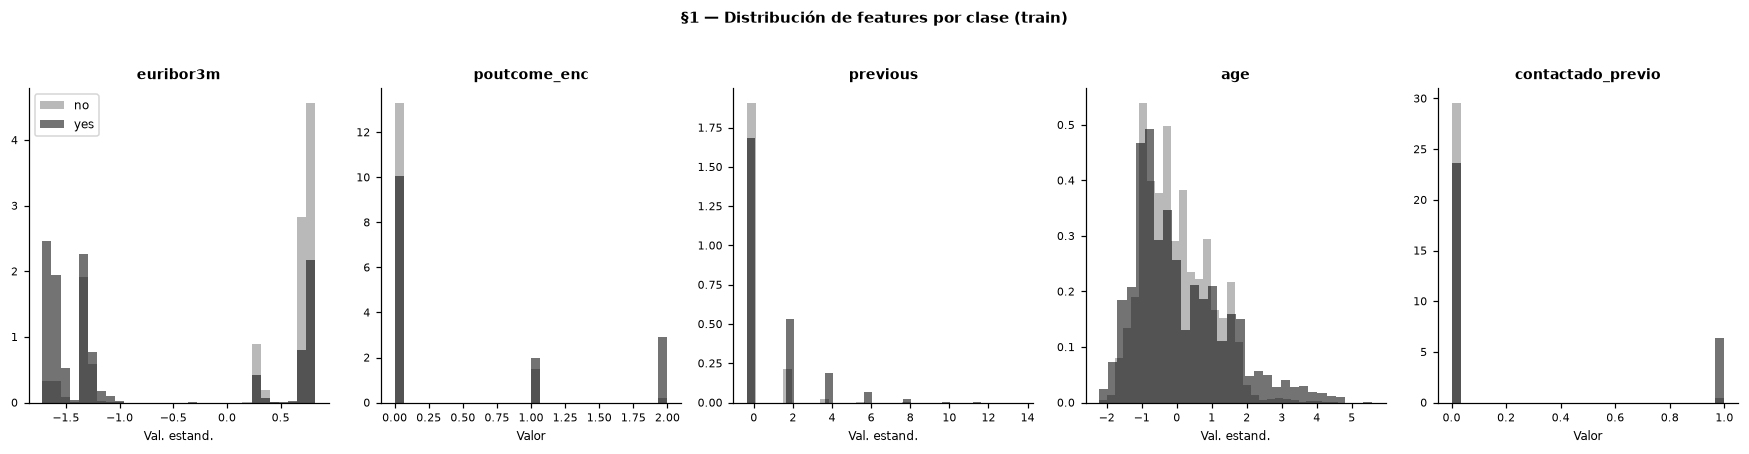

In [6]:
# §1.6 — Distribución de features por clase (train)
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, feat in zip(axes, FEATURES):
    vals_no  = X_train_sc[feat][y_train == 0]
    vals_yes = X_train_sc[feat][y_train == 1]
    ax.hist(vals_no,  bins=30, alpha=0.55, label='no',  color='gray',  density=True)
    ax.hist(vals_yes, bins=30, alpha=0.55, label='yes', color='black', density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Val. estand.' if feat in NUM_FEATURES else 'Valor', fontsize=8)
    ax.tick_params(labelsize=7)
    if feat == FEATURES[0]:
        ax.legend(fontsize=8)
fig.suptitle('§1 — Distribución de features por clase (train)',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 1.3 Resumen de preparación

| Decisión | Elección | Justificación |
|---|---|---|
| Valores NaN | Sin tratamiento | No existen NaN reales (S1) |
| Valores unknown | Conservar como categoría | Bajo porcentaje; potencialmente informativos |
| Outliers `age` | Conservar | Subgrupo real; eliminación invierte signo t (S2 §5.2) |
| `duration` | Excluida | Proxy post-hoc del target — data leakage |
| `pdays` | Binaria `contactado_previo` | 96.3 % = 999; tasa 63.8 % vs 9.3 % |
| Split | 70 % train / 30 % test estratificado | Mantiene desbalance 88.7 %/11.3 % |
| Estandarización | Solo `euribor3m`, `previous`, `age` | Ordinales/binarias no requieren escala |
| Features | `euribor3m`, `poutcome_enc`, `previous`, `age`, `contactado_previo` | Validadas en S1 y S2; sin multicolinealidad severa |

**Objetos disponibles para §2 (Carolina):** `X_train_sc`, `X_test_sc`, `y_train`, `y_test`, `FEATURES`, `NUM_FEATURES`, `BIN_FEATURES`, `scaler`.